## Instead of 2 months, train on 24 months to see if there is an impact
- Downloaded 22 more zip files and placed them in the data directory.
- I copied the code from the previous notebook

In [1]:
from pathlib import Path
import zipfile
import pandas as pd

DATA_DIR = Path("../data/raw_consumption_by_fsa")

def load_month(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        csv_name = z.namelist()[0]

        with z.open(csv_name) as f:
            df = pd.read_csv(f, skiprows=3)

    return df

In [2]:
all_dfs = []

for zip_file in sorted(DATA_DIR.glob("*.zip")):
    print(f"Loading {zip_file.name}")

    df = load_month(zip_file)

    all_dfs.append(df)

raw_df = pd.concat(all_dfs, ignore_index=True)

print(raw_df.shape)

Loading PUB_HourlyConsumptionByFSA_202403_v1.zip
Loading PUB_HourlyConsumptionByFSA_202404_v1.zip
Loading PUB_HourlyConsumptionByFSA_202405_v1.zip
Loading PUB_HourlyConsumptionByFSA_202406_v1.zip
Loading PUB_HourlyConsumptionByFSA_202407_v1.zip
Loading PUB_HourlyConsumptionByFSA_202408_v1.zip
Loading PUB_HourlyConsumptionByFSA_202409_v1.zip
Loading PUB_HourlyConsumptionByFSA_202410_v1.zip
Loading PUB_HourlyConsumptionByFSA_202411_v1.zip
Loading PUB_HourlyConsumptionByFSA_202412_v1.zip
Loading PUB_HourlyConsumptionByFSA_202501_v1.zip
Loading PUB_HourlyConsumptionByFSA_202502_v1.zip
Loading PUB_HourlyConsumptionByFSA_202503_v1.zip
Loading PUB_HourlyConsumptionByFSA_202504_v1.zip
Loading PUB_HourlyConsumptionByFSA_202505_v1.zip
Loading PUB_HourlyConsumptionByFSA_202506_v1.zip
Loading PUB_HourlyConsumptionByFSA_202507_v1.zip
Loading PUB_HourlyConsumptionByFSA_202508_v1.zip
Loading PUB_HourlyConsumptionByFSA_202509_v1.zip
Loading PUB_HourlyConsumptionByFSA_202510_v1.zip
Loading PUB_HourlyCo

### Create Timestamp

In [3]:
raw_df["timestamp"] = (
    pd.to_datetime(raw_df["DATE"])
    + pd.to_timedelta(raw_df["HOUR"] - 1, unit="h")
)

### Aggregate to Ontario-Wide Consumption

In [4]:
ontario_hourly = (
    raw_df.groupby("timestamp", as_index=False)
          .agg({
              "TOTAL_CONSUMPTION": "sum",
              "PREMISE_COUNT": "sum"
          })
          .sort_values("timestamp")
)

In [5]:
ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
0,2024-03-01 00:00:00,5836805.9,5157604
1,2024-03-01 01:00:00,5539349.0,5157395
2,2024-03-01 02:00:00,5384500.4,5157581
3,2024-03-01 03:00:00,5311046.6,5158196
4,2024-03-01 04:00:00,5360169.0,5154730


In [6]:
ontario_hourly.tail()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
17515,2026-02-28 19:00:00,8.171924e+06,5295595
17516,2026-02-28 20:00:00,7.963853e+06,5295593
17517,2026-02-28 21:00:00,7.678498e+06,5295588
17518,2026-02-28 22:00:00,7.263470e+06,5295588
17519,2026-02-28 23:00:00,6.819851e+06,5297273


In [7]:
ontario_hourly.shape

(17520, 3)

### Verify Continuity
Very important for time-series.

In [8]:
ontario_hourly["timestamp"].diff().value_counts()

timestamp
0 days 01:00:00    17519
Name: count, dtype: int64

### Plot

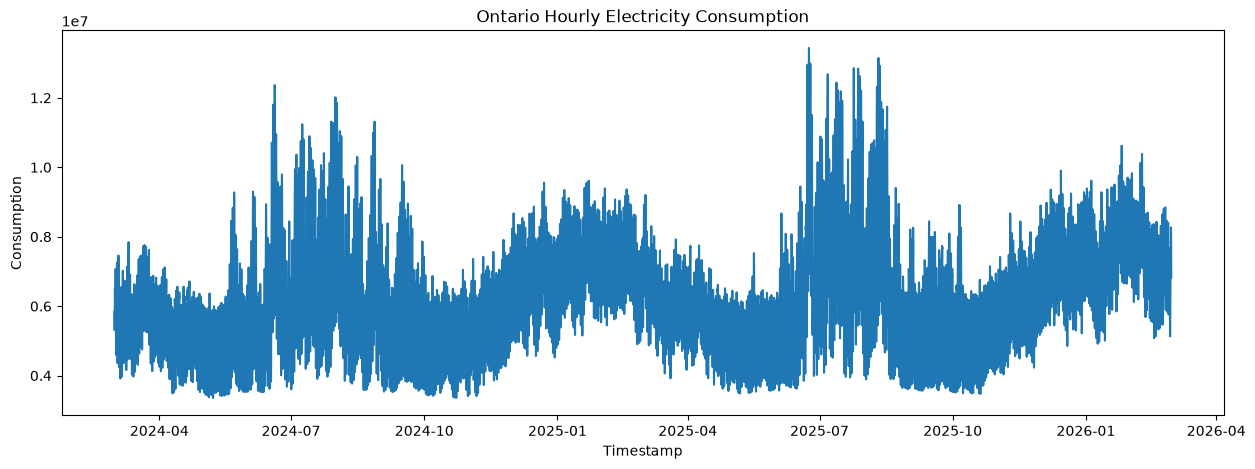

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    ontario_hourly["timestamp"],
    ontario_hourly["TOTAL_CONSUMPTION"]
)

plt.title("Ontario Hourly Electricity Consumption")
plt.xlabel("Timestamp")
plt.ylabel("Consumption")
plt.show()

### Make sure it's sorted

In [10]:
ontario_hourly = ontario_hourly.sort_values("timestamp").reset_index(drop=True)

### Create features

In [11]:
ontario_hourly["hour"] = ontario_hourly["timestamp"].dt.hour
ontario_hourly["day_of_week"] = ontario_hourly["timestamp"].dt.dayofweek
ontario_hourly["month"] = ontario_hourly["timestamp"].dt.month
ontario_hourly["day_of_month"] = ontario_hourly["timestamp"].dt.day


In [12]:
ontario_hourly["lag_1"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(1)
)

ontario_hourly["lag_24"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(24)
)

ontario_hourly["lag_168"] = (
    ontario_hourly["TOTAL_CONSUMPTION"].shift(168)
)

In [13]:
ontario_hourly["rolling_mean_24"] = (
    ontario_hourly["TOTAL_CONSUMPTION"]
    .rolling(24)
    .mean()
)

ontario_hourly["rolling_mean_168"] = (
    ontario_hourly["TOTAL_CONSUMPTION"]
    .rolling(168)
    .mean()
)

In [14]:
ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT,hour,day_of_week,month,day_of_month,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
0,2024-03-01 00:00:00,5836805.9,5157604,0,4,3,1,NaN,NaN,NaN,NaN,NaN
1,2024-03-01 01:00:00,5539349.0,5157395,1,4,3,1,5836805.9,NaN,NaN,NaN,NaN
2,2024-03-01 02:00:00,5384500.4,5157581,2,4,3,1,5539349.0,NaN,NaN,NaN,NaN
3,2024-03-01 03:00:00,5311046.6,5158196,3,4,3,1,5384500.4,NaN,NaN,NaN,NaN
4,2024-03-01 04:00:00,5360169.0,5154730,4,4,3,1,5311046.6,NaN,NaN,NaN,NaN


In [15]:
model_df = ontario_hourly.dropna().copy()

model_df.shape

(17352, 12)

In [16]:
FEATURES = [
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168"
]

TARGET = "TOTAL_CONSUMPTION"

X = model_df[FEATURES]
y = model_df[TARGET]

In [17]:
split_idx = int(len(model_df) * 0.8)

train = model_df.iloc[:split_idx]
test = model_df.iloc[split_idx:]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

### Naive prediction (24 hours ago used as current hour consumption)

In [22]:
from sklearn.metrics import mean_absolute_error

baseline_pred = test["lag_24"]

mae_lag24 = mean_absolute_error(
    y_test,
    baseline_pred
)

print("Baseline MAE:", round(mae_lag24, 2))
print("XGBoost MAE :", round(mae_xgb, 2))

Baseline MAE: 304677.59
XGBoost MAE : 85838.92


# XGBoost Forecasting Model

An XGBoost regressor is trained using engineered temporal and lag-based features.

Advantages of XGBoost include:

- Strong performance on tabular data
- Fast training times
- Built-in feature importance analysis

The model is evaluated using a time-based train/test split to avoid information leakage.

In [18]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [19]:
predictions = xgb_model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae_xgb = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print(f"MAE: {mae_xgb:,.2f}")
print(f"RMSE: {rmse:,.2f}")

MAE: 85,838.92
RMSE: 114,596.29


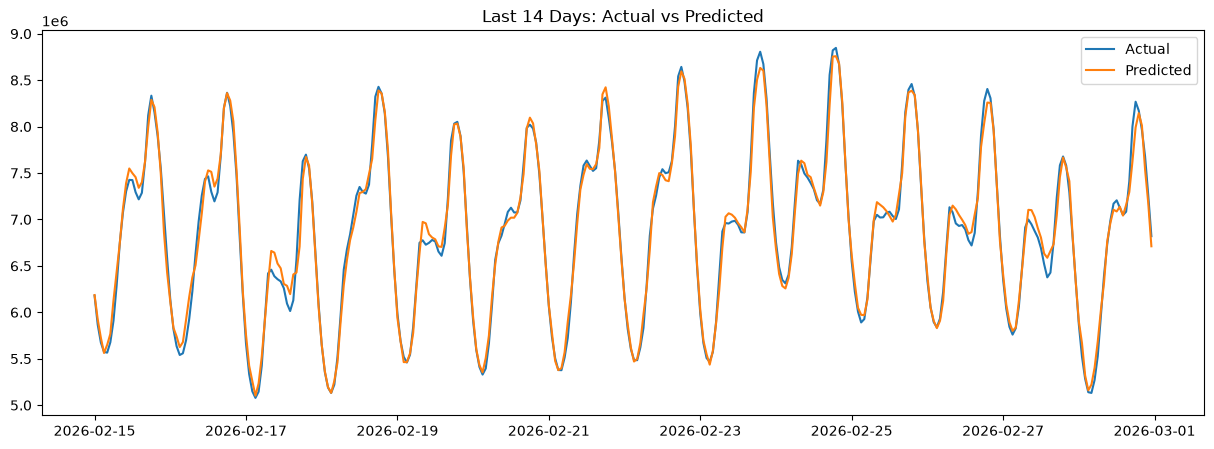

In [21]:
last_n = 24 * 14  # 14 days

plt.figure(figsize=(15, 5))

plt.plot(
    test["timestamp"].iloc[-last_n:],
    y_test.iloc[-last_n:],
    label="Actual"
)

plt.plot(
    test["timestamp"].iloc[-last_n:],
    predictions[-last_n:],
    label="Predicted"
)

plt.legend()
plt.title("Last 14 Days: Actual vs Predicted")
plt.show()

In [23]:
# percentage 
mape = (
    abs((y_test - predictions) / y_test)
).mean() * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 1.27%


In [24]:
feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_model.feature_importances_
})

feature_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
4,lag_1,0.799783
5,lag_24,0.170619
0,hour,0.018974
7,rolling_mean_24,0.003288
2,month,0.003269
1,day_of_week,0.001602
6,lag_168,0.001287
8,rolling_mean_168,0.000810
3,day_of_month,0.000368


### Compare XGBoost to baseline

In [25]:
baseline_pred = test["lag_1"]

mae_lag1 = mean_absolute_error(
    y_test,
    baseline_pred
)

print(mae_lag1)
print(mae_xgb)


255916.97350708384
85838.91673469375


# LSTM Forecasting Model

A Long Short-Term Memory (LSTM) neural network is implemented using PyTorch.

Unlike XGBoost, the LSTM learns directly from sequences of historical observations.

In [26]:
series = ontario_hourly[["timestamp", "TOTAL_CONSUMPTION"]].copy()

series.head()

,timestamp,TOTAL_CONSUMPTION
0,2024-03-01 00:00:00,5836805.9
1,2024-03-01 01:00:00,5539349.0
2,2024-03-01 02:00:00,5384500.4
3,2024-03-01 03:00:00,5311046.6
4,2024-03-01 04:00:00,5360169.0


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

series["scaled_consumption"] = scaler.fit_transform(
    series[["TOTAL_CONSUMPTION"]]
)

In [28]:
import numpy as np

SEQ_LENGTH = 168

X = []
y = []

values = series["scaled_consumption"].values

for i in range(SEQ_LENGTH, len(values)):
    X.append(values[i-SEQ_LENGTH:i])
    y.append(values[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(17352, 168)
(17352,)


In [29]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(17352, 168, 1)


In [30]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [31]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [32]:
import torch.nn as nn


class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        return self.fc(last_output)

In [33]:
model = LSTMModel()

In [34]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
EPOCHS = 10

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(
        outputs.squeeze(),
        y_train
    )

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Loss: {loss.item():.6f}"
    )

Epoch 1/10, Loss: 0.146996
Epoch 2/10, Loss: 0.136854
Epoch 3/10, Loss: 0.127448
Epoch 4/10, Loss: 0.118693
Epoch 5/10, Loss: 0.110498
Epoch 6/10, Loss: 0.102800
Epoch 7/10, Loss: 0.095549
Epoch 8/10, Loss: 0.088707
Epoch 9/10, Loss: 0.082239
Epoch 10/10, Loss: 0.076115


In [36]:
model.eval()

with torch.no_grad():

    predictions = (
        model(X_test)
        .squeeze()
        .numpy()
    )

In [37]:
predictions_actual = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

y_actual = scaler.inverse_transform(
    y_test.numpy().reshape(-1, 1)
)

In [38]:
from sklearn.metrics import mean_absolute_error

mae_lstm_1 = mean_absolute_error(
    y_actual,
    predictions_actual
)

print("LSTM MAE:", mae_lstm_1)

LSTM MAE: 2588594.0


In [39]:
print(predictions.min())
print(predictions.max())

print(y_test.min().item())
print(y_test.max().item())

0.07617074
0.080552734
0.011562332510948181
0.720865786075592


In [40]:
print(predictions_actual[:10].flatten())
print(y_actual[:10].flatten())

[4.1293412e+06 4.1304085e+06 4.1315850e+06 4.1327252e+06 4.1335718e+06
 4.1341300e+06 4.1346668e+06 4.1356165e+06 4.1370038e+06 4.1382272e+06]
[5.5070560e+06 5.6757775e+06 5.7742945e+06 5.7127935e+06 5.6392585e+06
 5.7119765e+06 6.0606960e+06 6.4587675e+06 6.5121215e+06 6.5955410e+06]


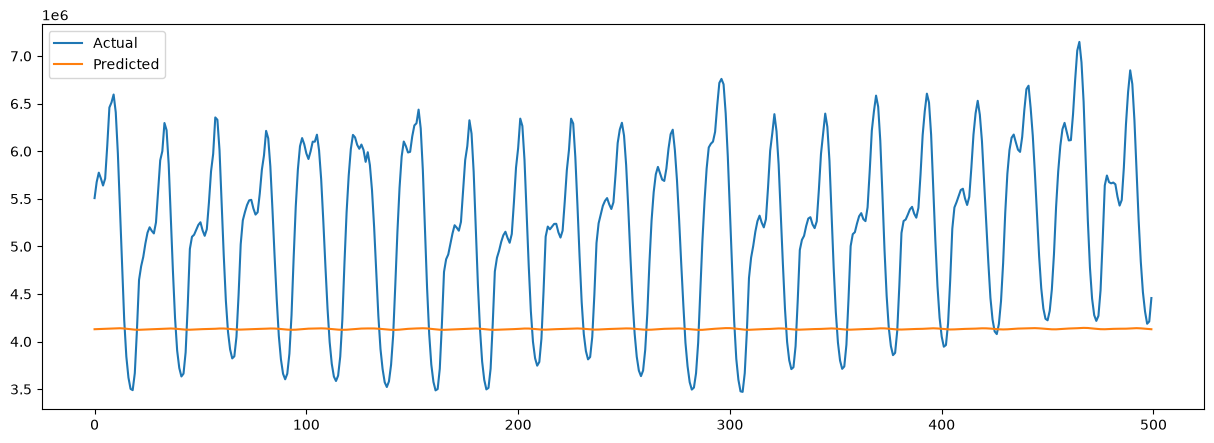

In [41]:
plt.figure(figsize=(15,5))

plt.plot(y_actual[:500], label="Actual")
plt.plot(predictions_actual[:500], label="Predicted")

plt.legend()
plt.show()

In [42]:
print("Naive MAE is:", round(mae_lag1, 2), "which is better than the current LSTM:", round(mae_lstm_1, 2))

Naive MAE is: 255916.97 which is better than the current LSTM: 2588594.0


## Change the parameters and try again

- shorter sequence (24 hours)
- larger hidden layer (64)
- mini-batch training
- more epochs (50)

In [43]:
series = ontario_hourly[["timestamp", "TOTAL_CONSUMPTION"]].copy()

series.head()

,timestamp,TOTAL_CONSUMPTION
0,2024-03-01 00:00:00,5836805.9
1,2024-03-01 01:00:00,5539349.0
2,2024-03-01 02:00:00,5384500.4
3,2024-03-01 03:00:00,5311046.6
4,2024-03-01 04:00:00,5360169.0


In [44]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

series["scaled_consumption"] = scaler.fit_transform(
    series[["TOTAL_CONSUMPTION"]]
)

In [45]:
import numpy as np

SEQ_LENGTH = 24

X = []
y = []

values = series["scaled_consumption"].values

for i in range(SEQ_LENGTH, len(values)):
    X.append(values[i-SEQ_LENGTH:i])
    y.append(values[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(17496, 24)
(17496,)


In [46]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(17496, 24, 1)


In [47]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [48]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [49]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

In [50]:
import torch.nn as nn


class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        return self.fc(last_output)

In [51]:
model = LSTMModel()

In [52]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [53]:
EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(
            outputs.squeeze(),
            batch_y
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/50, Loss: 0.020462
Epoch 2/50, Loss: 0.005727
Epoch 3/50, Loss: 0.003626
Epoch 4/50, Loss: 0.002141
Epoch 5/50, Loss: 0.001355
Epoch 6/50, Loss: 0.000960
Epoch 7/50, Loss: 0.000751
Epoch 8/50, Loss: 0.000595
Epoch 9/50, Loss: 0.000451
Epoch 10/50, Loss: 0.000321
Epoch 11/50, Loss: 0.000230
Epoch 12/50, Loss: 0.000184
Epoch 13/50, Loss: 0.000161
Epoch 14/50, Loss: 0.000153
Epoch 15/50, Loss: 0.000144
Epoch 16/50, Loss: 0.000134
Epoch 17/50, Loss: 0.000123
Epoch 18/50, Loss: 0.000119
Epoch 19/50, Loss: 0.000121
Epoch 20/50, Loss: 0.000124
Epoch 21/50, Loss: 0.000127
Epoch 22/50, Loss: 0.000128
Epoch 23/50, Loss: 0.000128
Epoch 24/50, Loss: 0.000127
Epoch 25/50, Loss: 0.000126
Epoch 26/50, Loss: 0.000122
Epoch 27/50, Loss: 0.000119
Epoch 28/50, Loss: 0.000116
Epoch 29/50, Loss: 0.000114
Epoch 30/50, Loss: 0.000112
Epoch 31/50, Loss: 0.000110
Epoch 32/50, Loss: 0.000109
Epoch 33/50, Loss: 0.000107
Epoch 34/50, Loss: 0.000106
Epoch 35/50, Loss: 0.000105
Epoch 36/50, Loss: 0.000103
E

In [54]:
model.eval()

with torch.no_grad():

    predictions = (
        model(X_test)
        .squeeze()
        .numpy()
    )

In [55]:
predictions_actual = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

y_actual = scaler.inverse_transform(
    y_test.numpy().reshape(-1, 1)
)

In [56]:
from sklearn.metrics import mean_absolute_error

mae_lstm_2 = mean_absolute_error(
    y_actual,
    predictions_actual
)

print("LSTM MAE:", mae_lstm_2)

LSTM MAE: 76038.0859375


In [57]:
print(predictions.min())
print(predictions.max())

print(y_test.min().item())
print(y_test.max().item())

0.013168482
0.7557105
0.011562332510948181
0.720865786075592


In [58]:
print(predictions_actual[:10].flatten())
print(y_actual[:10].flatten())

[3.8802950e+06 4.2425580e+06 4.8738485e+06 5.1749910e+06 5.1027010e+06
 5.7080555e+06 6.2681935e+06 6.5747210e+06 7.0576005e+06 7.2355725e+06]
[3.8350018e+06 4.2478715e+06 4.7302575e+06 4.9615455e+06 5.3041760e+06
 5.8022810e+06 6.2577960e+06 6.6917420e+06 6.9657030e+06 7.2232035e+06]


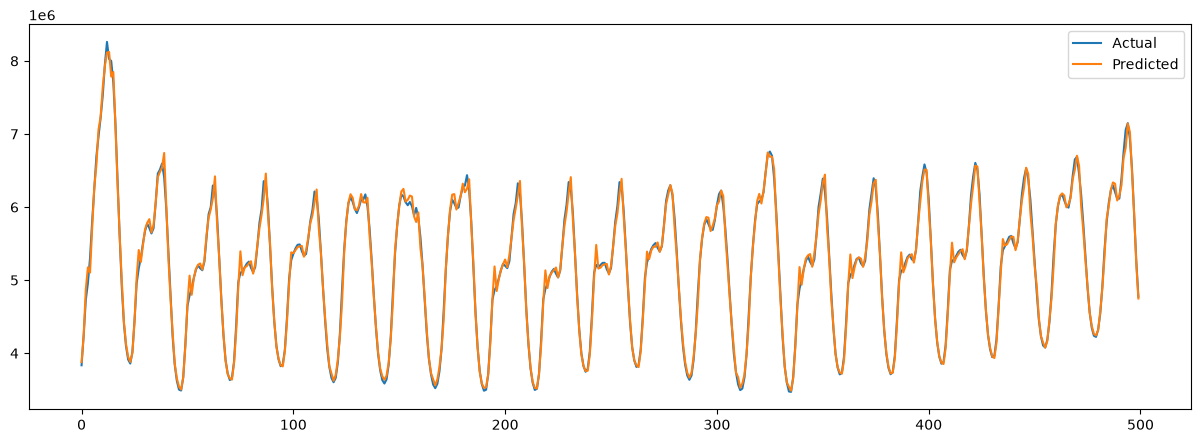

In [59]:
plt.figure(figsize=(15,5))

plt.plot(y_actual[:500], label="Actual")
plt.plot(predictions_actual[:500], label="Predicted")

plt.legend()
plt.show()

In [60]:
print("MAE Errors")
print("Baseline last hour:", round(mae_lag1, 2))
print("Baseline 24 hours ago:", round(mae_lag24, 2))
print("XGBoost:", round(mae_xgb, 2))
print("LSTM attempt 1:", round(mae_lstm_1, 2))
print("LSTM attempt 2:", round(mae_lstm_2, 2))

MAE Errors
Baseline last hour: 255916.97
Baseline 24 hours ago: 304677.59
XGBoost: 85838.92
LSTM attempt 1: 2588594.0
LSTM attempt 2: 76038.09


In [61]:
# Save both models
import joblib

joblib.dump(xgb_model, "../models/xgboost.pkl")

torch.save(
    model.state_dict(),
    "../models/lstm.pth"
)

# Results Comparison

The forecasting approaches are compared using Mean Absolute Error (MAE).

| Model | MAE |
|---------|---------:|
| Naïve Baseline | 255,917 |
| XGBoost | 85,839 |
| LSTM | 76,038 |

Key observations:

- Both machine learning models significantly outperform the naïve baseline.
- The LSTM achieved the lowest forecasting error and outperformed XGBoost.

# Conclusions

This project demonstrates the development of an end-to-end electricity demand forecasting system using real-world Ontario electricity consumption data.

Key outcomes:

- Built a scalable data ingestion pipeline from monthly ZIP archives.
- Engineered temporal and lag-based forecasting features.
- Reduced forecast error substantially relative to a naïve baseline.
- Successfully implemented and compared both XGBoost and PyTorch LSTM models.
- Found that sequence-based deep learning provided a modest improvement over gradient-boosted trees.

Future work could incorporate:

- Weather data
- Holiday effects
- Multi-step forecasting
- FSA-level demand forecasting
- Transformer-based forecasting models